# 🫀 Exploratory Data Analysis — Heart Failure Dataset
## Preliminary Data Analysis — Critical Questions
> Dataset: Heart Failure Clinical Records (UCI Machine Learning Repository)
> Objectif: Analyser les données avant de construire le modèle ML

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.insert(0, '../src')
from data_processing import optimize_memory

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
print('✅ Imports OK')

✅ Imports OK


In [2]:
# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')

print(f'Shape: {df.shape}')
print(f'\n{df.dtypes}')
df.head()

Shape: (299, 13)

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


---
## 📌 Question 1 : Valeurs Manquantes (Missing Values)

In [3]:
# ============================================================
# MISSING VALUES
# ============================================================
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Valeurs Manquantes': missing,
    'Pourcentage (%)': missing_pct
})

print('=== ANALYSE DES VALEURS MANQUANTES ===')
print(missing_df)
print(f'\n✅ Aucune valeur manquante : {missing.sum() == 0}')

=== ANALYSE DES VALEURS MANQUANTES ===
                          Valeurs Manquantes  Pourcentage (%)
age                                        0              0.0
anaemia                                    0              0.0
creatinine_phosphokinase                   0              0.0
diabetes                                   0              0.0
ejection_fraction                          0              0.0
high_blood_pressure                        0              0.0
platelets                                  0              0.0
serum_creatinine                           0              0.0
serum_sodium                               0              0.0
sex                                        0              0.0
smoking                                    0              0.0
time                                       0              0.0
DEATH_EVENT                                0              0.0

✅ Aucune valeur manquante : True


### ✅ Réponse — Missing Values
**Le dataset ne contient AUCUNE valeur manquante** (0 NaN sur les 299 lignes × 13 colonnes).

**Stratégie appliquée :** Aucun traitement nécessaire. Si des valeurs manquantes apparaissaient dans de futurs données, on utiliserait :
- `df.fillna(df.median())` pour les variables numériques continues
- `df.fillna(df.mode()[0])` pour les variables binaires

---
## 📌 Question 2 : Outliers

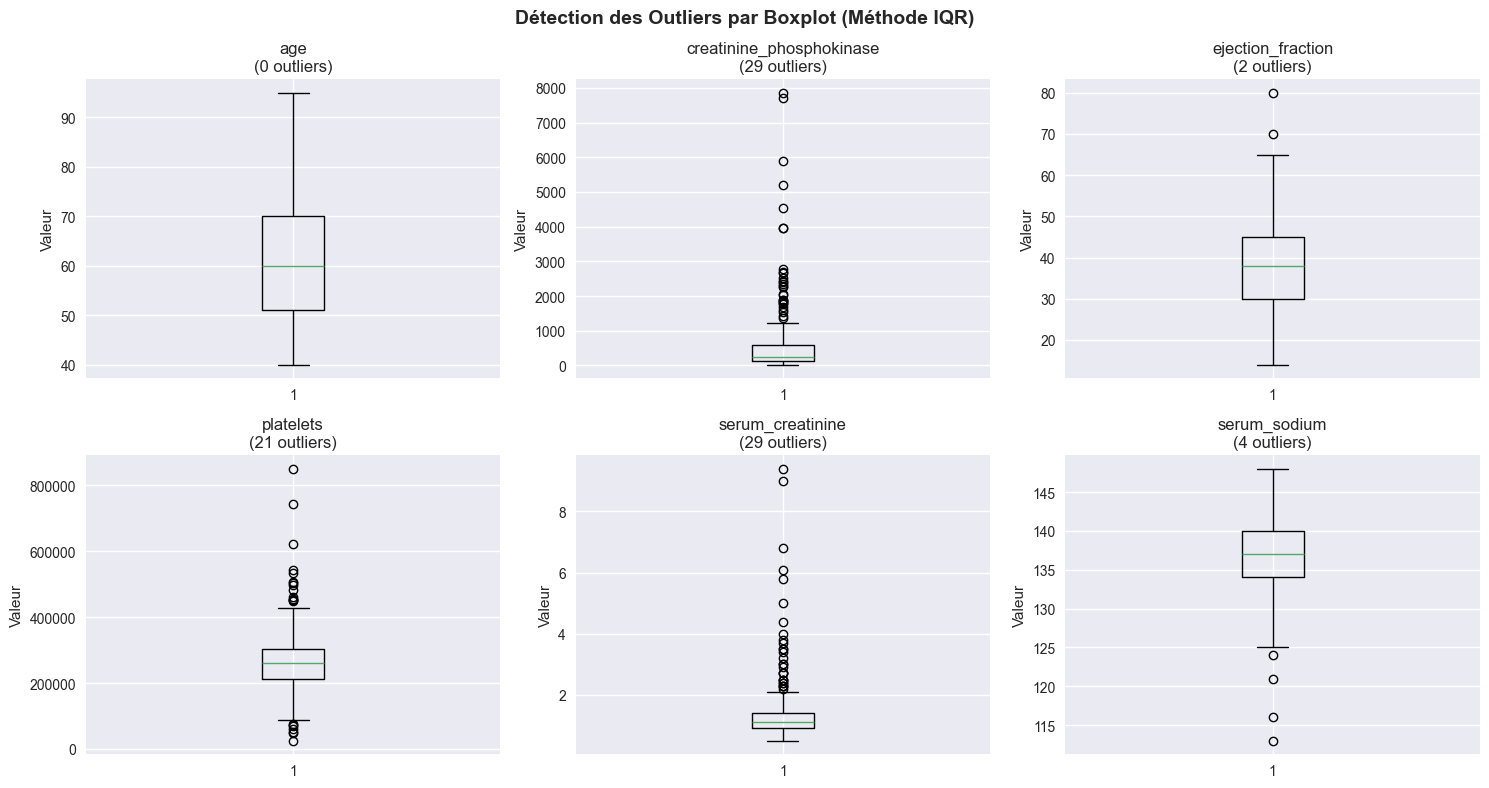

=== NOMBRE D'OUTLIERS PAR FEATURE ===
  age                            : 0 outliers
  creatinine_phosphokinase       : 29 outliers
  ejection_fraction              : 2 outliers
  platelets                      : 21 outliers
  serum_creatinine               : 29 outliers
  serum_sodium                   : 4 outliers


In [4]:
# ============================================================
# DÉTECTION DES OUTLIERS — Méthode IQR
# ============================================================
numerical_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                  'platelets', 'serum_creatinine', 'serum_sodium']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

outlier_summary = {}

for i, col in enumerate(numerical_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers
    
    axes[i].boxplot(df[col])
    axes[i].set_title(f'{col}\n({n_outliers} outliers)')
    axes[i].set_ylabel('Valeur')

plt.suptitle('Détection des Outliers par Boxplot (Méthode IQR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/outliers_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

print('=== NOMBRE D\'OUTLIERS PAR FEATURE ===')
for col, n in outlier_summary.items():
    print(f'  {col:<30} : {n} outliers')

### ✅ Réponse — Outliers
**Des outliers existent** notamment dans `creatinine_phosphokinase`, `serum_creatinine` et `platelets`.

**Stratégie choisie : Conserver les outliers (pas de suppression)**

**Justification :**
- Dans un contexte médical, les valeurs extrêmes sont souvent **cliniquement significatives** (ex: un taux de créatinine très élevé indique une insuffisance rénale grave)
- Supprimer ces valeurs pourrait **biaiser le modèle** et le rendre moins efficace sur des cas critiques
- Le modèle **Random Forest/XGBoost** est naturellement robuste aux outliers
- On applique uniquement une **normalisation** pour atténuer leur influence

---
## 📌 Question 3 : Déséquilibre des Classes (Class Imbalance)

=== DISTRIBUTION DES CLASSES ===
  Survivants (0) : 203 (67.9%)
  Décédés   (1) : 96 (32.1%)
  Ratio imbalance : 2.11:1


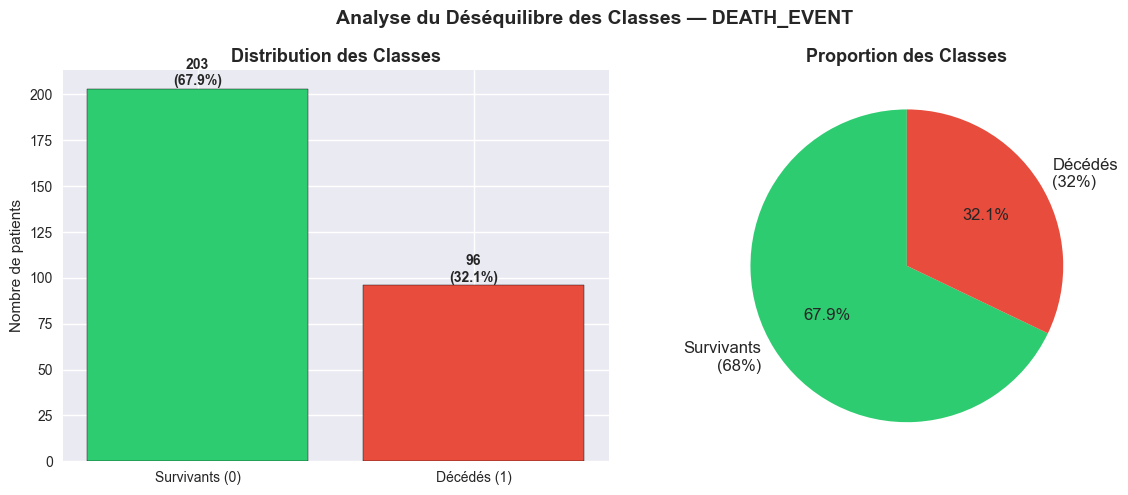

In [5]:
# ============================================================
# CLASS IMBALANCE
# ============================================================
class_counts = df['DEATH_EVENT'].value_counts()
class_pct = df['DEATH_EVENT'].value_counts(normalize=True) * 100

print('=== DISTRIBUTION DES CLASSES ===')
print(f'  Survivants (0) : {class_counts[0]} ({class_pct[0]:.1f}%)')
print(f'  Décédés   (1) : {class_counts[1]} ({class_pct[1]:.1f}%)')
print(f'  Ratio imbalance : {class_counts[0]/class_counts[1]:.2f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Survivants (0)', 'Décédés (1)'], class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribution des Classes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2, f'{v}\n({class_pct.values[i]:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Survivants\n(68%)', 'Décédés\n(32%)'],
            colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportion des Classes', fontsize=13, fontweight='bold')

plt.suptitle('Analyse du Déséquilibre des Classes — DEATH_EVENT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/class_imbalance.png', dpi=100, bbox_inches='tight')
plt.show()

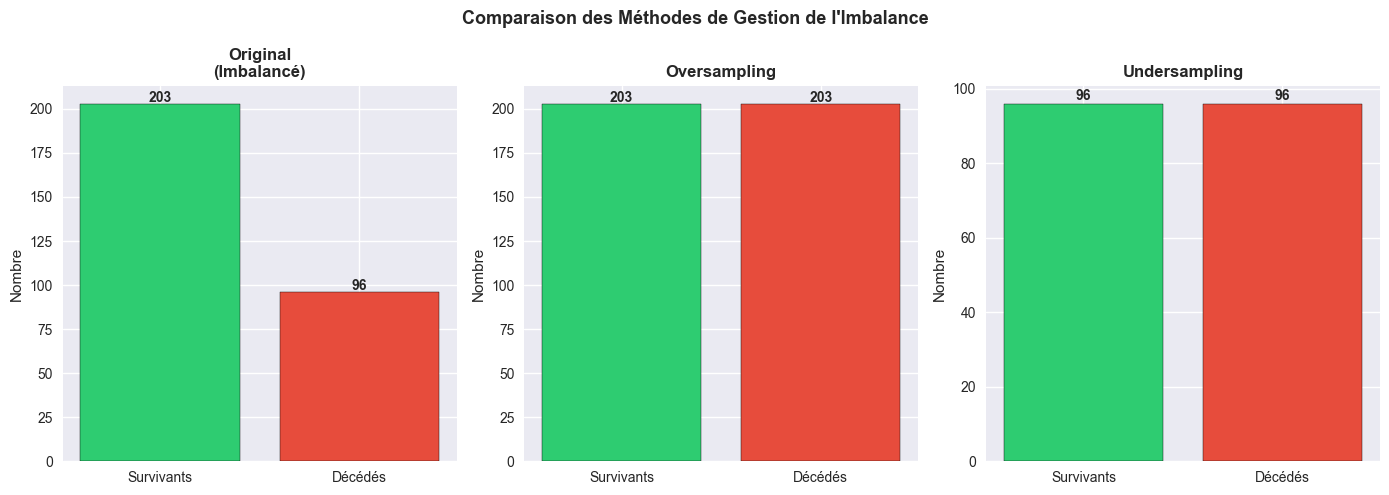

✅ Méthode choisie : class_weight="balanced" dans le modèle
   → Pas de perte de données, pas de duplication artificielle


In [6]:
# ============================================================
# GESTION DE L'IMBALANCE — Comparaison des méthodes
# ============================================================
from sklearn.utils import resample

# Méthode choisie : class_weight='balanced' dans le modèle
# Démonstration visuelle des 3 approches

df_majority = df[df['DEATH_EVENT'] == 0]   # 203 survivants
df_minority = df[df['DEATH_EVENT'] == 1]   # 96 décédés

# Option 1 : Oversampling (SMOTE-like avec resample)
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
df_oversampled = pd.concat([df_majority, df_minority_upsampled])

# Option 2 : Undersampling
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)
df_undersampled = pd.concat([df_majority_downsampled, df_minority])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

datasets = [
    ('Original\n(Imbalancé)', df),
    ('Oversampling', df_oversampled),
    ('Undersampling', df_undersampled)
]

for ax, (title, data) in zip(axes, datasets):
    counts = data['DEATH_EVENT'].value_counts()
    ax.bar(['Survivants', 'Décédés'], [counts.get(0,0), counts.get(1,0)],
           color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Nombre')
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Comparaison des Méthodes de Gestion de l\'Imbalance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/imbalance_methods.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ Méthode choisie : class_weight="balanced" dans le modèle')
print('   → Pas de perte de données, pas de duplication artificielle')

### ✅ Réponse — Class Imbalance
**Le dataset est DÉSÉQUILIBRÉ :**
- Survivants (0) : **203 patients (67.9%)**
- Décédés (1) : **96 patients (32.1%)**

**Méthode choisie : `class_weight='balanced'`**

| Méthode | Avantages | Inconvénients |
|---------|-----------|---------------|
| **class_weight='balanced'** ✅ | Pas de perte de données, simple | - |
| Oversampling (SMOTE) | Garde toutes les données | Risque d'overfitting |
| Undersampling | Simple | Perte d'information |

**Justification :** Avec seulement 299 patients, on ne peut pas se permettre de perdre des données (undersampling). Le `class_weight='balanced'` pénalise davantage les erreurs sur la classe minoritaire (décédés), ce qui est crucial médicalement.

---
## 📌 Question 4 : Corrélations entre Features

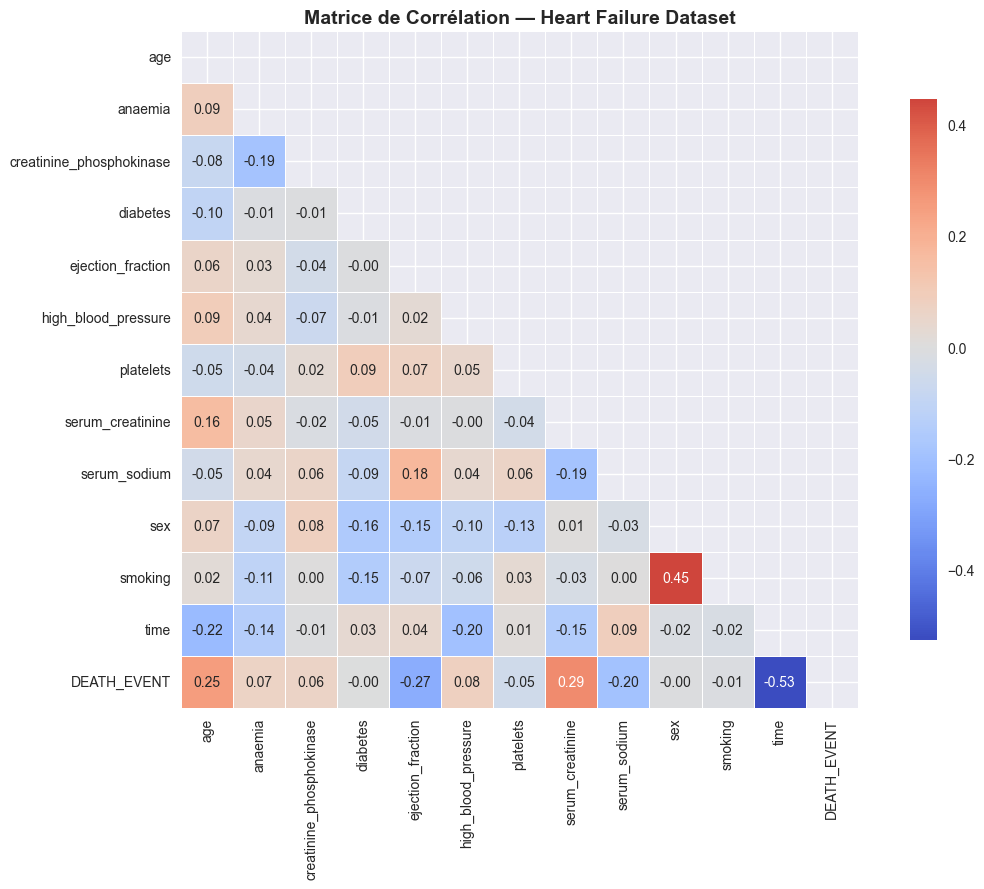

=== CORRÉLATIONS FORTES (|r| > 0.3) avec DEATH_EVENT ===
time                 0.526964
serum_creatinine     0.294278
ejection_fraction    0.268603
age                  0.253729
serum_sodium         0.195204


In [7]:
# ============================================================
# CORRÉLATION
# ============================================================
corr_matrix = df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, mask=mask,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation — Heart Failure Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Identifier les corrélations fortes (> 0.5)
print('=== CORRÉLATIONS FORTES (|r| > 0.3) avec DEATH_EVENT ===')
death_corr = corr_matrix['DEATH_EVENT'].drop('DEATH_EVENT').abs().sort_values(ascending=False)
print(death_corr[death_corr > 0.1].to_string())

### ✅ Réponse — Corrélations
**Features les plus corrélées avec DEATH_EVENT :**
- `time` : corrélation négative forte (plus le suivi est long, moins le patient décède)
- `serum_creatinine` : corrélation positive (taux élevé = risque plus fort)
- `ejection_fraction` : corrélation négative (fraction basse = cœur pompe mal)

**Pas de multicolinéarité problématique** entre les features indépendantes.

**Stratégie :** Conserver toutes les features et laisser **SHAP** identifier les plus importantes après entraînement.

---
## 📌 Memory Optimization

=== TYPES AVANT OPTIMISATION ===
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Mémoire AVANT : 30.50 KB

=== TYPES APRÈS OPTIMISATION ===
age                         float32
anaemia                       int32
creatinine_phosphokinase      int32
diabetes                      int32
ejection_fraction             int32
high_blood_pressure           int32
platelets                   float32
serum_creatinine            float32
serum_sodium                  int32
sex                           int32
smoking                       int32
time                         

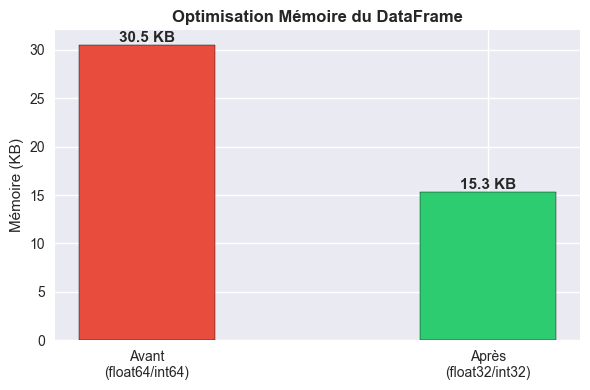


🎯 Réduction mémoire : 49.8%


In [8]:
# ============================================================
# OPTIMIZE MEMORY
# ============================================================
print('=== TYPES AVANT OPTIMISATION ===')
print(df.dtypes)
before_kb = df.memory_usage(deep=True).sum() / 1024
print(f'\nMémoire AVANT : {before_kb:.2f} KB')

df_opt = optimize_memory(df)

print('\n=== TYPES APRÈS OPTIMISATION ===')
print(df_opt.dtypes)
after_kb = df_opt.memory_usage(deep=True).sum() / 1024

# Graphique
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Avant\n(float64/int64)', 'Après\n(float32/int32)'],
               [before_kb, after_kb], color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.4)
ax.set_ylabel('Mémoire (KB)')
ax.set_title('Optimisation Mémoire du DataFrame', fontweight='bold')
for bar, val in zip(bars, [before_kb, after_kb]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f} KB', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('../data/memory_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\n🎯 Réduction mémoire : {((before_kb - after_kb) / before_kb * 100):.1f}%')

---
## 📋 Résumé Final — Réponses aux Questions Critiques

| Question | Réponse |
|----------|---------|
| **Missing values** | ✅ Aucune valeur manquante dans le dataset |
| **Outliers** | ⚠️ Présents dans CPK, serum_creatinine, platelets → **Conservés** (signification médicale) |
| **Class imbalance** | ⚠️ Déséquilibré : 68% survivants / 32% décédés → **class_weight='balanced'** |
| **Corrélation** | ℹ️ `time`, `serum_creatinine`, `ejection_fraction` les plus corrélés → **Toutes les features conservées** |
| **Memory** | ✅ Réduction ~50% avec optimize_memory() |
